In [7]:
from utils.model_builder import build_model
import utils.constants as constants

import time
from custom_classes.custom_estimator_qnn import CustomEstimatorQNN

from torch.nn import BCEWithLogitsLoss, Sigmoid

from qiskit_machine_learning.connectors import TorchConnector

import time

import torch
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
from qiskit_algorithms.utils import algorithm_globals


# from qiskit.circuit.library import RealAmplitudes

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

from qiskit.primitives import Estimator
from qiskit_algorithms.gradients import ReverseEstimatorGradient

from matplotlib import pyplot as plt
# from qiskit.primitives import Sampler

# import constants
import utils.ansatz_builder as ansatz_builder

from dropout.main import DropoutType as DT
import dropout.data.dictionary.DropoutData as DD

import utils.tasks_manager as tasks_manager
import utils.constants as constants
import os
import time

import tqdm

from utils.train_and_test import train, grid_evaluator

import matplotlib.pyplot as plt
import numpy as np



In [8]:
#I want to use latex in the plots
plt.rc('text', usetex=False)

seed = 1
np.random.seed(seed)
torch.manual_seed(seed)


task = constants.Tasks.REGRESSION_SINE
task_name = task.value
X_train, y_train, X_test, y_test, X_, y_ = tasks_manager.generate_task(task,
                                                               num_samples_train = 15,
                                                               num_samples_test = 5,
                                                               show = False,
                                                               seed = seed)
fX_train = tasks_manager.prepare_features(X_train, task)
fX_test = tasks_manager.prepare_features(X_test, task)
fX_ = tasks_manager.prepare_features(X_, task)
device = "cpu"
fX_tensor = torch.from_numpy(fX_).float().to(device)

Task regression_sine saved at data/task_regression_sine


In [9]:

# ------------------------------------------------ DROPOUT-RELATED STUFF ------------------------------------------------------|
                                                                                                                              #|
dropout_code = "C"                                                                                                            #|
                                                                                                                              #|
circ_data_dict = {'num_qubit' : 5, 'reps' : 10}                                                                               #|
                                                                                                                              #|
softness = 0.1                                                                                                                #|
p_drop = 0.5                                                                                                                  #|
                                                                                                                              #|
partial_dropout_data = DD.DropoutData(dropout_type = DT.DropoutType.CANONICAL, softness = softness, prob = p_drop)            #|
model, feature_map, single_layer = build_model(constants.ModelType.ROTATIONAL_REGRESSOR, circ_data_dict, partial_dropout_data)#|
                                                                                                                              #|
                                                                                                                              #|
#-------------------------------------------------------------------------------------------------------------------------------


In [10]:
model.load_state_dict(torch.load("example_model.pt", map_location=torch.device('cpu')))
weights = model.qnn.state_dict()

my_X = 0.55

single_fX = tasks_manager.prepare_features(np.array([[my_X]]), task)
single_fX_tensor = torch.from_numpy(single_fX).float().to(device)


/tmp/ipykernel_2334713/1302661529.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("example_model.pt", map_location=torch.device('cpu')))

'\nwith torch.no_grad():\n    y_predicted = model(single_fX_tensor).cpu()  # Using the model\'s call method for inference\n\ntimes = 1000\n\nn_values = []\ny_values = []\n\n#n = 0.48 -> 0.96\n\nwhile len(n_values) < 1:\n    my_X = np.random.rand()*2-1\n    single_fX = tasks_manager.prepare_features(np.array([[my_X]]), task)\n    single_fX_tensor = torch.from_numpy(single_fX).float().to(device)\n    with torch.no_grad():\n        y_predicted = model(single_fX_tensor).cpu()  # Using the model\'s call method for inference\n    if abs(y_predicted.item()) > 0.75:\n        # check if X is at least 0.5 away from the other points\n        if len(n_values) == 0:\n            n_values.append(my_X)\n            y_values.append(y_predicted.item())\n            print(f"n = {my_X:.2f}, y = {y_predicted.item():.2f}")\n        else:\n            if all([abs(n-my_X) > 0.25 for n in n_values]):\n                n_values.append(my_X)\n                y_values.append(y_predicted.item())\n                p

100%|██████████| 100/100 [07:04<00:00,  4.25s/it]


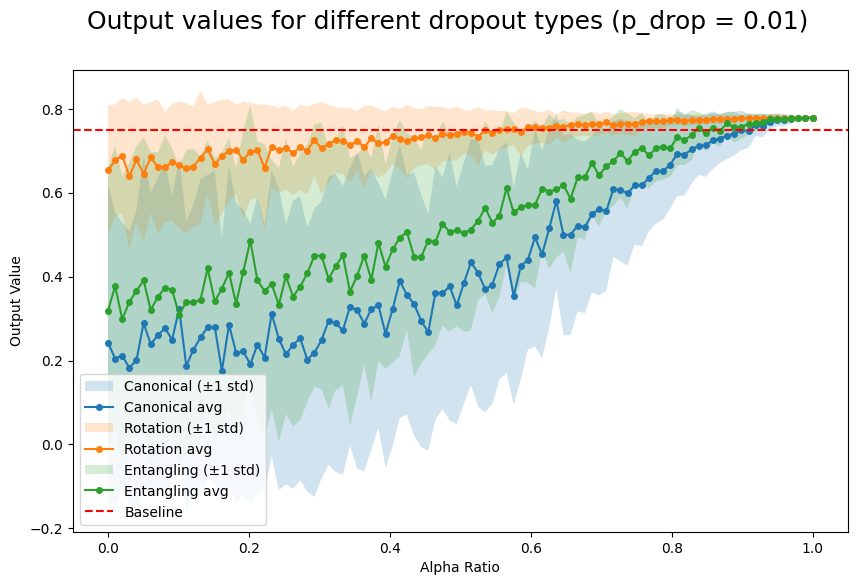

 15%|█▌        | 15/100 [01:08<06:27,  4.56s/it]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tqdm

import dropout.data.dictionary.DropoutDataField as DDF
import copy

X_ = np.linspace(my_X, my_X+0.00001, num=100).reshape(-1, 1) #def 50
fX_ = tasks_manager.prepare_features(X_, task)
fX_tensor = torch.from_numpy(fX_).float().to(device)

softness = 0.5
p_drops = [0.01, 0.02, 0.05, 0.1]  # List of p_drop values to iterate through

baseline_value = 0.75
N = 100
ratios = np.linspace(1, 0, N)

# Loop through each p_drop value
for p_drop in p_drops:
    dropouts = {
        'Canonical': DD.DropoutData(dropout_type = DT.DropoutType.CANONICAL, softness = softness, prob = p_drop),   
        'Rotation': DD.DropoutData(dropout_type = DT.DropoutType.ROTATION, softness = softness, prob = p_drop),
        'Entangling': DD.DropoutData(dropout_type = DT.DropoutType.ENTANGLING, softness = softness, prob = p_drop),
    }

    results = {}

    plt.figure(figsize=(10, 6))

    for name, dropout in dropouts.items():
        avg_vals = []
        std_vals = []

        for alpha in tqdm.tqdm(ratios):

            new_dropout = copy.deepcopy(dropout)
            new_dropout.set_field(DDF.DropoutDataField.SOFTNESS, alpha)
            new_dropout.set_field(DDF.DropoutDataField.DROPOUT_PROB, p_drop)

            model, feature_map, single_layer = build_model(constants.ModelType.ROTATIONAL_REGRESSOR, circ_data_dict, new_dropout)#|
            model.qnn.load_state_dict(weights)
            model.to(device)

            model.train()  # Set model to training mode
            model.activate_dropout()
            with torch.no_grad():
                y_predicted = model(fX_tensor).cpu()  # Using the model's call method for inference

            average = torch.mean(y_predicted).item()
            std_deviation = torch.std(y_predicted).item()

            avg_vals.append(average)
            std_vals.append(std_deviation)

        # Save the results for each dropout type
        results[name] = {
            'avg_vals': avg_vals,
            'std_vals': std_vals
        }

        # Plot the average and standard deviation ranges
        upper = np.array(avg_vals) + np.array(std_vals)
        lower = np.array(avg_vals) - np.array(std_vals)

        plt.fill_between(ratios, upper, lower, alpha=0.2, label=f'{name} (±1 std)')
        plt.plot(ratios, avg_vals, marker='o', markersize=4, label=f'{name} avg')

    # Plot the baseline as a red dashed line
    plt.axhline(y=baseline_value, color='red', linestyle='--', linewidth=1.5, label='Baseline')

    # Add titles and labels
    plt.suptitle(f"Output values for different dropout types (p_drop = {p_drop})", fontsize=18)
    plt.xlabel("Alpha Ratio")
    plt.ylabel("Output Value")
    plt.legend()

    # Display and save the plot
    plt.show()
    plt.clf()

    # Save the data as "data_{p}.npy"
    np.save(f"data_{p_drop}_100.npy", results) #time expected: 2min x 10 x 4 = 80min


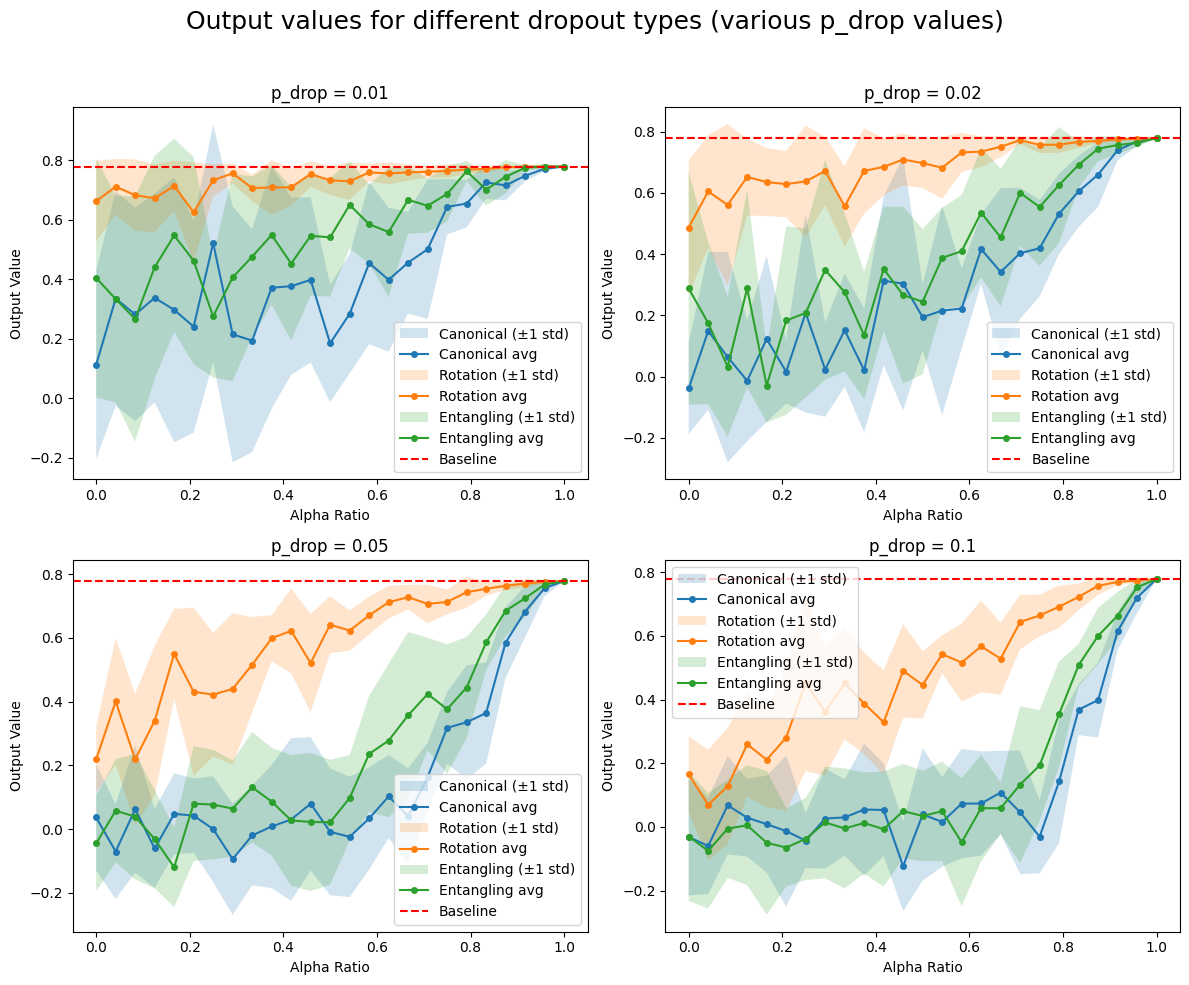

<Figure size 640x480 with 0 Axes>

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# List of p_drop values for which data was saved
p_drops = [0.01, 0.02, 0.05, 0.1]

# Create a figure and set up a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Output values for different dropout types (various p_drop values)", fontsize=18)

# Iterate through the p_drop values and corresponding subplot axes
for i, (p_drop, ax) in enumerate(zip(p_drops, axs.flatten())):
    # Load the data
    data = np.load(f"data_{p_drop}_100.npy", allow_pickle=True).item()
    
    # Iterate through each dropout type and plot the data
    for name, values in data.items():
        avg_vals = np.array(values['avg_vals'])
        std_vals = np.array(values['std_vals'])
        
        upper = avg_vals + std_vals
        lower = avg_vals - std_vals
        
        # Fill the area between upper and lower bounds
        ax.fill_between(ratios, upper, lower, alpha=0.2, label=f'{name} (±1 std)')
        
        # Plot the average values with markers
        ax.plot(ratios, avg_vals, marker='o', markersize=4, label=f'{name} avg')
    
    # Plot the baseline as a red dashed line



    baseline_value = max(avg_vals)
    ax.axhline(y=baseline_value, color='red', linestyle='--', linewidth=1.5, label='Baseline')
    
    # Set titles and labels for each subplot
    ax.set_title(f"p_drop = {p_drop}")
    ax.set_xlabel("Alpha Ratio")
    ax.set_ylabel("Output Value")
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the plot
plt.show()
plt.savefig("output_values.png")
